# **INN Hotels**

## **Problem Statement**

### **Business Context:**
A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.


The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.


The cancellation of bookings impacts a hotel on various fronts:

1. Loss of resources (revenue) when the hotel cannot resell the room.
2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
3. Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
4. Human resources to make arrangements for the guests.

### **Objective:**
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

### **Data Dictionary**

- Booking_ID: the unique identifier of each booking

- no_of_adults: Number of adults

- no_of_children: Number of Children

- no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

- no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel

- type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast Meal
    * Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)

- required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)

- room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group

- lead_time: Number of days between the date of booking and the arrival date

- arrival_year: Year of arrival date

- arrival_month: Month of arrival date

- arrival_date: Date of the month

- market_segment_type: Market segment designation.

- repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)

- no_of_previous_cancellations: Number of previous bookings that were canceled by the customer before the current booking

- no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer before the current booking

- avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)

- no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)

- booking_status: Flag indicating if the booking was canceled or not.

## **Installing & Loading Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## **Loading the Dataset**

In [4]:
df = pd.read_csv(r'/Users/himanshuneeraj/Documents/AAFT Classes /Semester -2 /Machine Learning /H project/INNHotelsGroup.csv')
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [5]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [6]:
df.shape

(36275, 19)

> **Observation** : There's 36275 entries and 19 columns in the dataset.


#### **Checking the data types of the columns for the dataset**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

> **Observation** : There's 14 numerical columns and 5 categorical columns

#### **Statistical Summary of the Data**

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


#### **Checking for Null Values**

In [9]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

> **Observation** : No null values in this dataset

## **Univariate Analysis**

**Categorical Variables**:
 Bar plots and count plots to visualize the categorical distribution of values

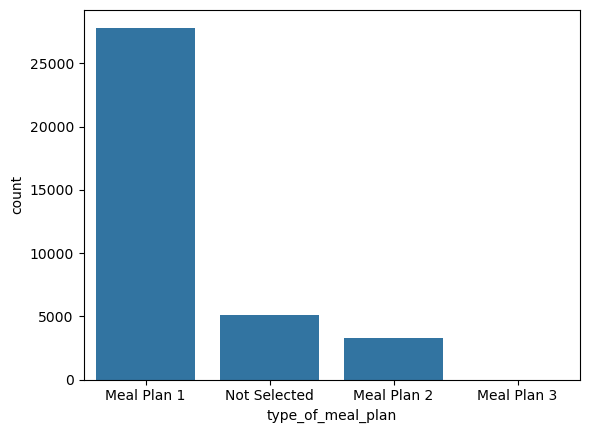

In [10]:
sns.countplot(x='type_of_meal_plan', data=df)
plt.show()

In [11]:
# Observations
#'Meal Plan 1' is the most popular meal plan among hotel guests.

**Numerical Variables**:
 Hist plots and Box plots to visualize the numerical distribution of values

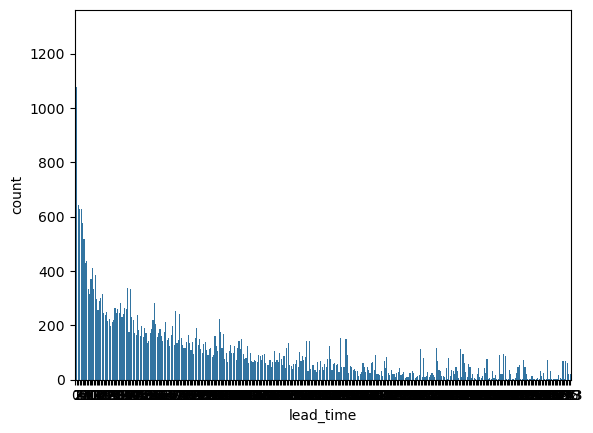

In [12]:
sns.countplot(x='lead_time', data=df)
plt.show()

In [13]:
# Observations:
#The histogram reveals a right-skewed distribution for booking lead times, suggesting the hotel receives the bulk of reservations with shorter lead times while a small segment plans well in advance. This understanding can guide inventory management, marketing strategies, and revenue optimization for the hotel."

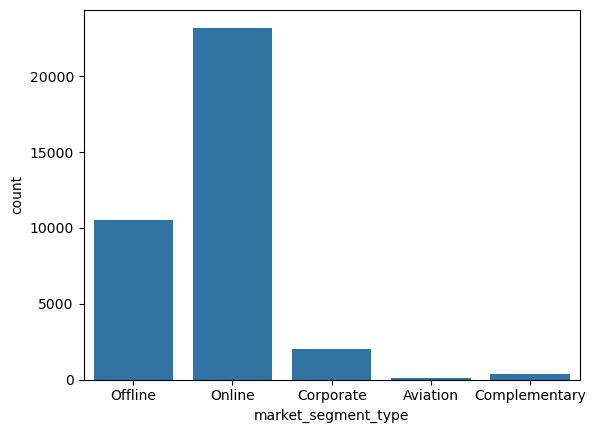

In [14]:
sns.countplot(x='market_segment_type', data=df)
plt.show()

In [15]:
# Observations:
#The market segment with the tallest bar which Online here is the most common source of bookings for the hotel

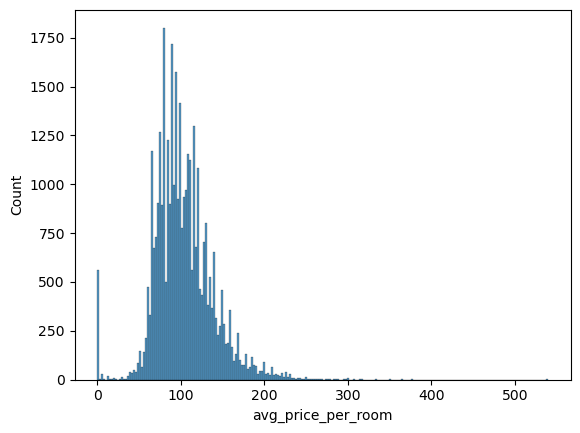

In [16]:
sns.histplot(x='avg_price_per_room', data=df)
plt.show()

In [17]:
#Observations:
#The histogram shows the distribution of average room prices, likely with a right skew and a concentration around a typical price range.

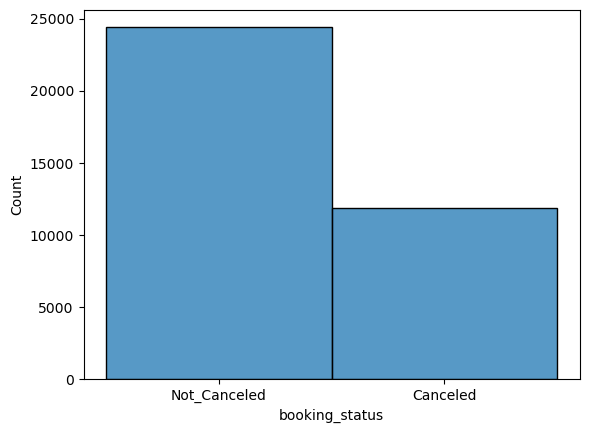

In [18]:
sns.histplot(x='booking_status', data=df)
plt.show()

In [19]:
#Observations:
#The histogram displays the frequency of bookings that were either "Canceled" or "Not Canceled"

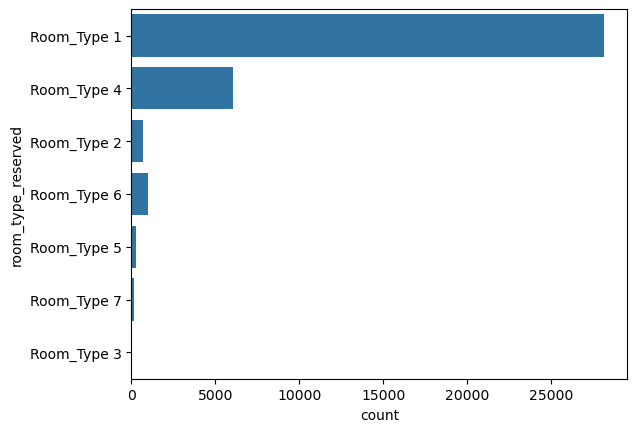

In [20]:
sns.countplot(y='room_type_reserved', data=df)
plt.show()

In [21]:
#Observations:
#The count plot shows the frequency of each room type reserved, with 'Room_Type 1' being the most frequently booked.

## **Bivariate Analysis**

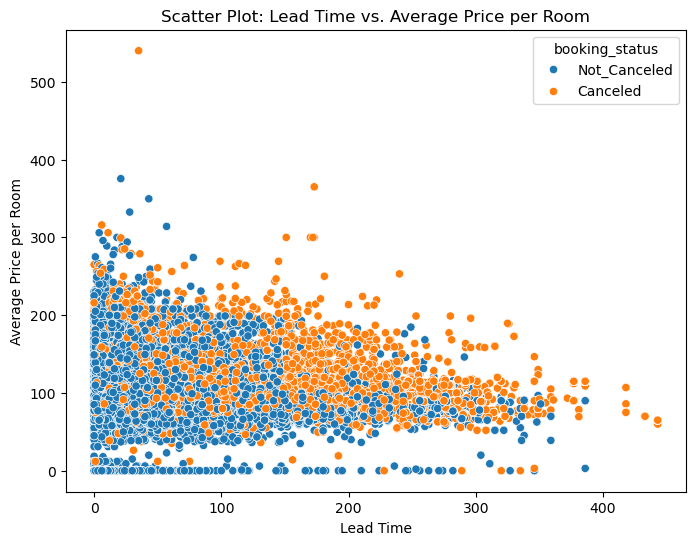

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='lead_time', y='avg_price_per_room', data=df, hue='booking_status')
plt.title('Scatter Plot: Lead Time vs. Average Price per Room')
plt.xlabel('Lead Time')
plt.ylabel('Average Price per Room')
plt.show()

In [23]:
#Observations:
#The scatter plot visualizes the relationship between lead time and average room price, colored by booking status (canceled or not canceled).

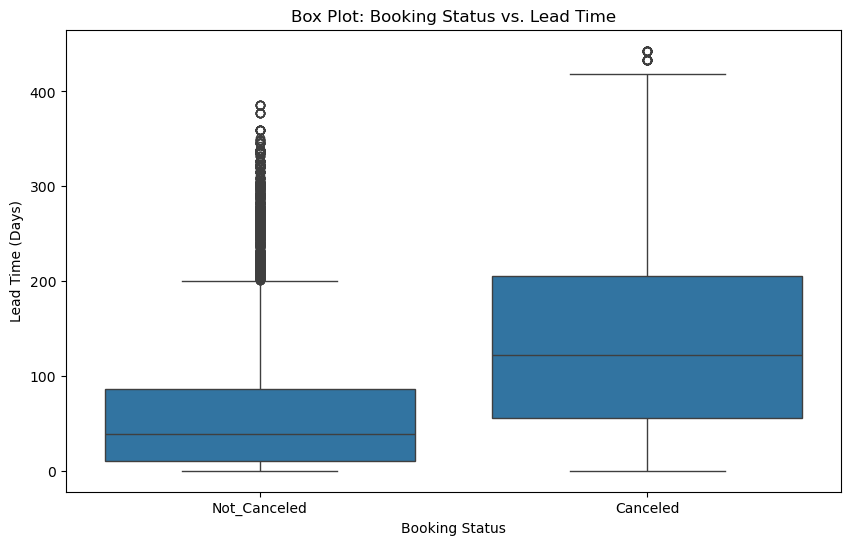

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title('Box Plot: Booking Status vs. Lead Time')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (Days)')
plt.show()

In [25]:
#Observations:
#"The box plot reveals that canceled bookings generally have longer lead times compared to bookings that are not canceled. This suggests that guests who book further in advance are more prone to cancellations. The hotel could consider implementing policies or incentives to encourage shorter lead times or early confirmations for reservations made well in advance."

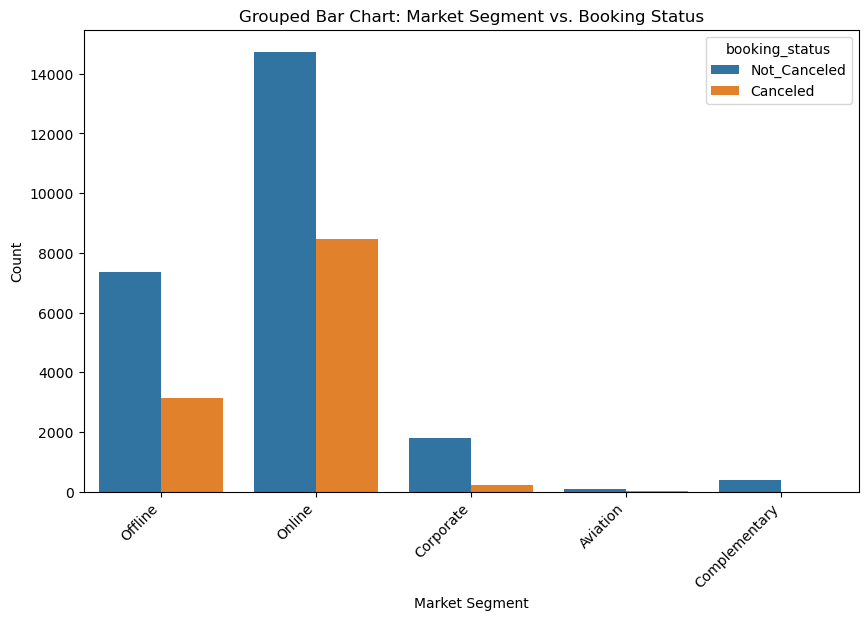

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.title('Grouped Bar Chart: Market Segment vs. Booking Status')
plt.xlabel('Market Segment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
plt.show()

In [27]:
#Observations:
#"The grouped bar chart indicates that the 'Online TA' segment has a higher proportion of canceled bookings compared to other segments. This suggests that customers acquired through online travel agencies might be more prone to cancellations. The hotel could consider implementing stricter cancellation policies or offering incentives for non-refundable bookings for this segment."

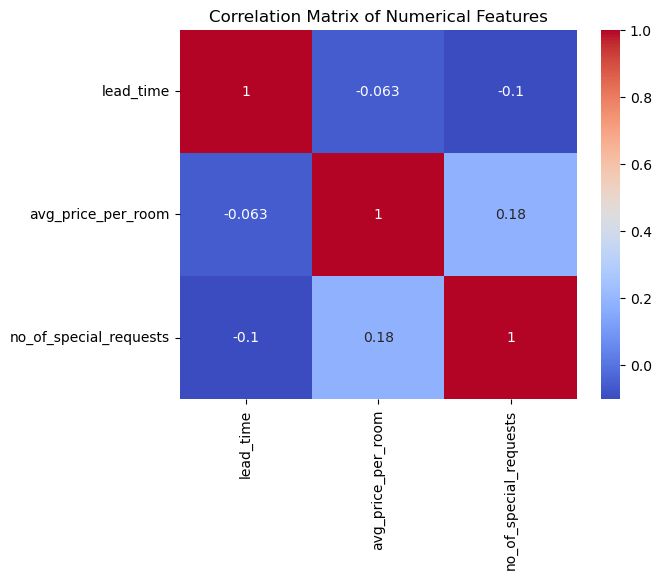

In [28]:
numerical_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [29]:
#Observations:
#Lead Time and Average Price: You might observe a weak positive correlation, suggesting that bookings made further in advance tend to have slightly higher prices, but the relationship is not very strong.
#Lead Time and Special Requests: There might be a weak positive correlation, indicating that guests who book further in advance are slightly more likely to have special requests.
#Average Price and Special Requests: There might be a weak to moderate positive correlation, suggesting that guests who pay higher prices for rooms tend to make more special requests.

**Question 1 : What are the busiest months in the hotel?**

In [30]:
bookings_by_month = df.groupby('arrival_month')['Booking_ID'].count().reset_index()
bookings_by_month.rename(columns={'Booking_ID': 'Number of Bookings'})
bookings_by_month

,arrival_month,Booking_ID
0,1,1014
1,2,1704
2,3,2358
3,4,2736
4,5,2598
5,6,3203
6,7,2920
7,8,3813
8,9,4611
9,10,5317


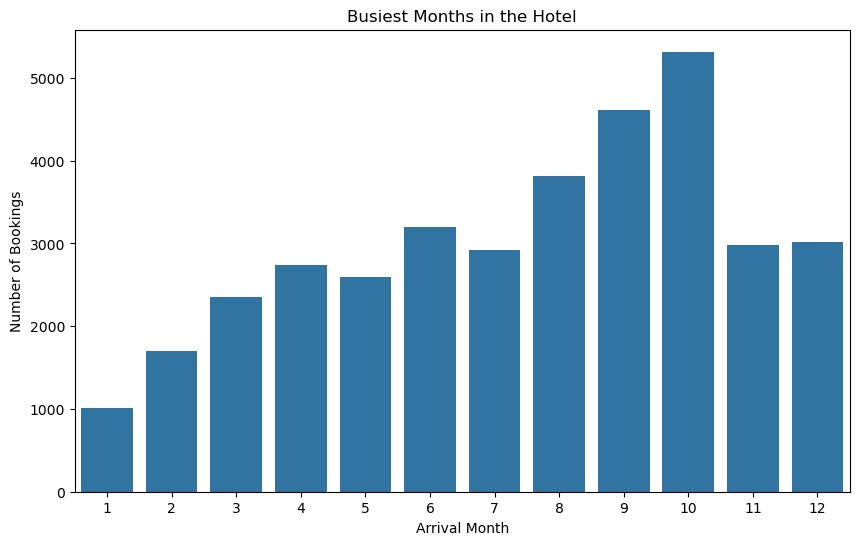

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='arrival_month', y='Booking_ID', data=bookings_by_month)
plt.title('Busiest Months in the Hotel')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')
plt.show()

In [32]:
#Observations:
#The bar plot shows that October is the busiest month for the hotel, followed by September. The slowest months are January and February, indicating lower demand during the winter season."


**Question 2 : Which market segment do most of the guests come from?**

In [33]:
market_segment_counts = df.groupby('market_segment_type')['Booking_ID'].count().reset_index()
market_segment_counts.rename(columns={'Booking_ID': 'Number of Bookings'}, inplace=True)

In [34]:
most_common_segment = market_segment_counts.loc[market_segment_counts['Number of Bookings'].idxmax()]
print(f"The most common market segment is: {most_common_segment['market_segment_type']}")

The most common market segment is: Online


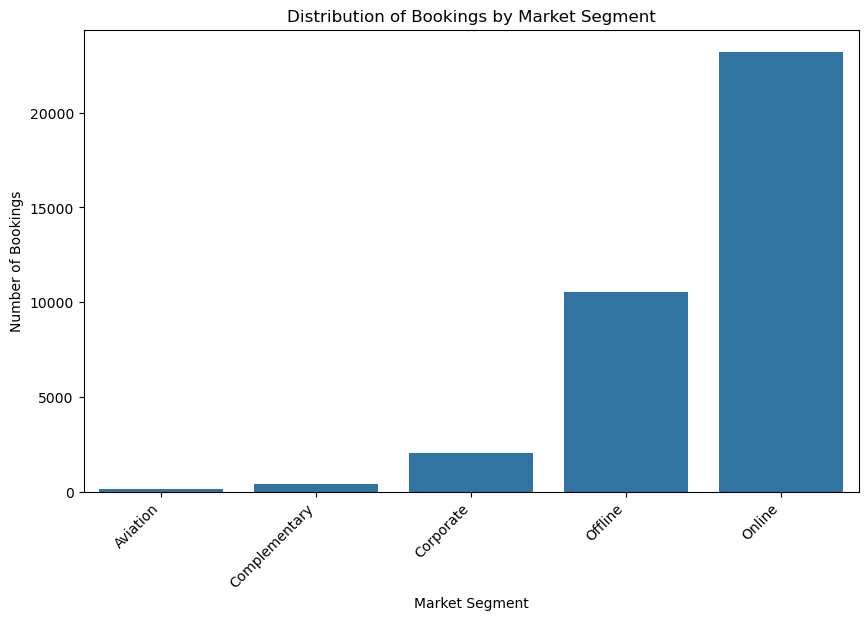

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment_type', y='Number of Bookings', data=market_segment_counts)
plt.title('Distribution of Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.show()

In [36]:
#Observations:
#The most common market segment is: Online mode from where most guests are coming.

**Question 3 : Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

In [37]:
#Calculate average room prices per market segment:
avg_prices_by_segment = df.groupby('market_segment_type')['avg_price_per_room'].mean().reset_index()

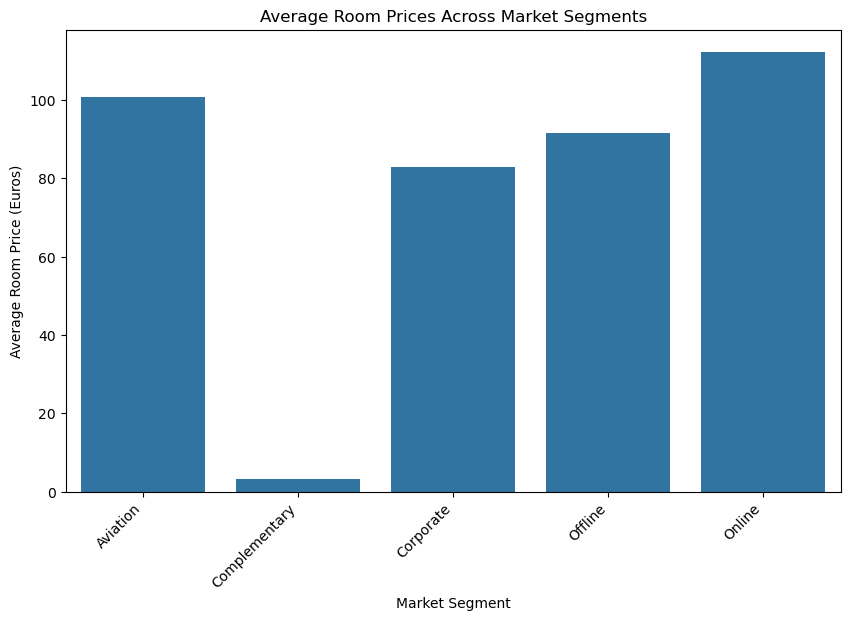

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment_type', y='avg_price_per_room', data=avg_prices_by_segment)
plt.title('Average Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [39]:
#Observations:
#"The bar plot reveals that the 'Groups' market segment has the lowest average room price, suggesting that the hotel offers discounted rates to attract group bookings. This could be a strategy to increase occupancy and revenue during periods of lower individual demand."

In [40]:
#box plots to visualize the distribution of room prices within each market segment, showing the median, quartiles, and potential outliers.

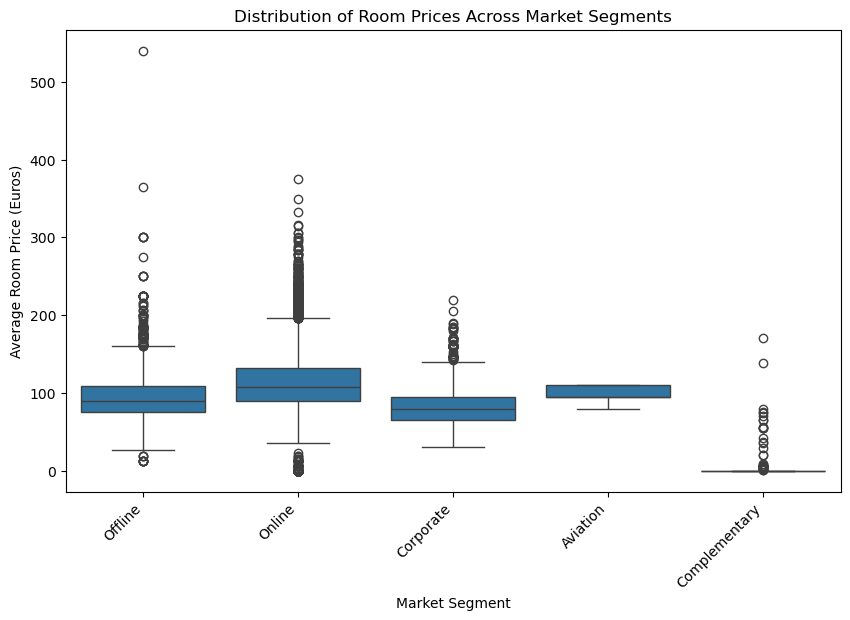

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title('Distribution of Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [42]:
#Observations:
#"The box plot shows that the 'Groups' market segment generally has lower and less variable room prices compared to other segments. This is consistent with the practice of offering discounts to attract group bookings and ensure price predictability for large groups."

**Question 4 : What percentage of bookings are canceled?**

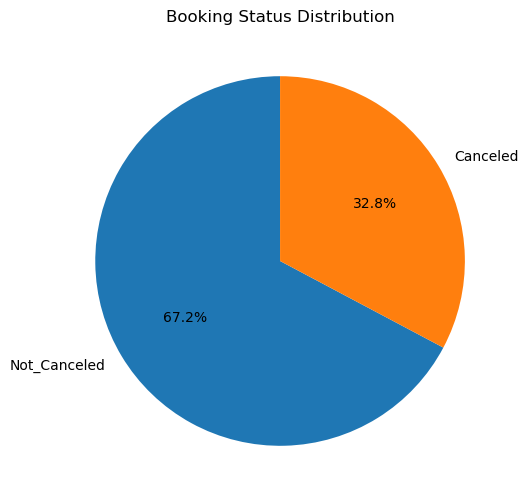

In [43]:
# Get booking status counts
booking_status_counts = df['booking_status'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(booking_status_counts, labels=booking_status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Booking Status Distribution')
plt.show()

In [44]:
#Observations:
# 32.8% bookings are cancelled.

**Question 5 : Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**


In [45]:
repeating_guests = df[df['repeated_guest'] == 1]

In [46]:
total_repeating_guests = len(repeating_guests)
canceled_repeating_guests = repeating_guests['booking_status'].value_counts()['Canceled']
percentage_canceled_repeating = (canceled_repeating_guests / total_repeating_guests) * 100
print(f"Percentage of repeating guests who cancel: {percentage_canceled_repeating:.2f}%")

Percentage of repeating guests who cancel: 1.72%


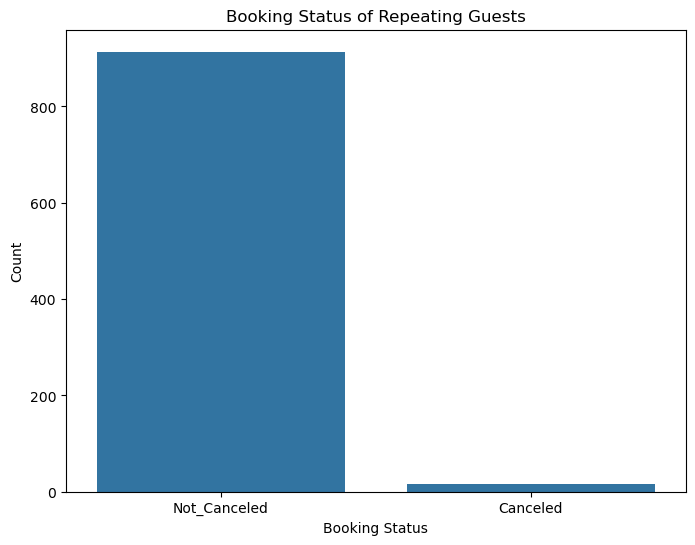

In [47]:
plt.figure(figsize=(8, 6))
sns.countplot(x='booking_status', data=repeating_guests)
plt.title('Booking Status of Repeating Guests')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()

In [48]:
#Observations:
# Percentage of repeating guests who cancel bookings: 1.72%

**Question 6 : Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

In [49]:
# Group data by 'no_of_special_requests' and 'booking_status' and count bookings
special_requests_impact = df.groupby(['no_of_special_requests', 'booking_status'])['Booking_ID'].count().reset_index()

# Rename the 'Booking_ID' column to 'count' for clarity
special_requests_impact.rename(columns={'Booking_ID': 'count'}, inplace=True)

# Calculate cancellation rates for each group
special_requests_impact['cancellation_rate'] = special_requests_impact.groupby('no_of_special_requests')['count'].transform(lambda x: x / x.sum())

# Filter for canceled bookings to get cancellation rates
special_requests_cancellation_rates = special_requests_impact[special_requests_impact['booking_status'] == 'Canceled']

# Display the cancellation rates
print(special_requests_cancellation_rates)

   no_of_special_requests booking_status  count  cancellation_rate
0                       0       Canceled   8545           0.432068
2                       1       Canceled   2703           0.237668
4                       2       Canceled    637           0.145967


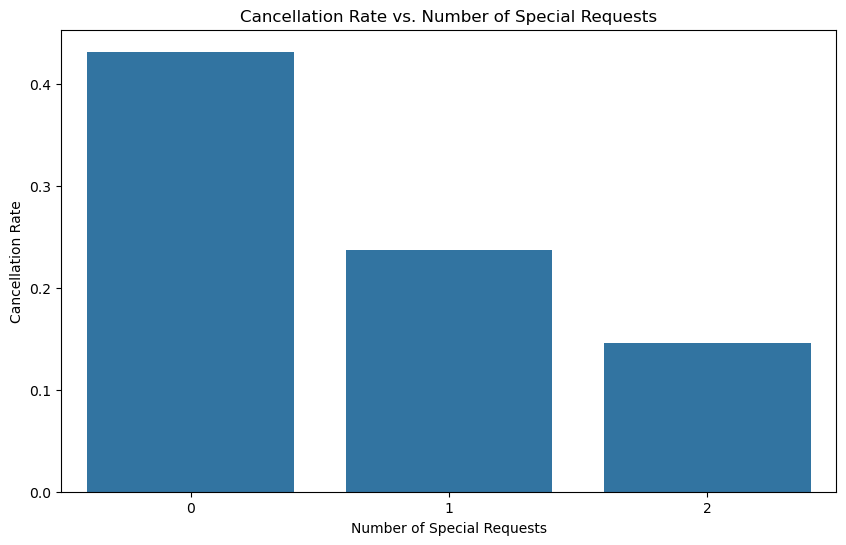

In [50]:
# visualize cancellation rates based on special requests
plt.figure(figsize=(10, 6))
sns.barplot(x='no_of_special_requests', y='cancellation_rate', data=special_requests_cancellation_rates)
plt.title('Cancellation Rate vs. Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate')
plt.show()

In [51]:
#Observations:
#We first group the data by the number of special requests and booking status to calculate the cancellation rate for each group.
#Then, used a bar plot to visualize the relationship between the number of special requests and the cancellation rate.
#The plot and the cancellation rates will help us understand if guests with special requests are more or less likely to cancel their bookings.

**Question 7 : Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

In [52]:
# Group data by 'no_of_special_requests' and 'booking_status' and count bookings
special_requests_impact = df.groupby(['no_of_special_requests', 'booking_status'])['Booking_ID'].count().reset_index()

# Rename the 'Booking_ID' column to 'count' for clarity
special_requests_impact.rename(columns={'Booking_ID': 'count'}, inplace=True)

# Calculate cancellation rates for each group
special_requests_impact['cancellation_rate'] = special_requests_impact.groupby('no_of_special_requests')['count'].transform(lambda x: x / x.sum())

# Filter for canceled bookings to get cancellation rates
special_requests_cancellation_rates = special_requests_impact[special_requests_impact['booking_status'] == 'Canceled']

# Display the cancellation rates
print(special_requests_cancellation_rates)

   no_of_special_requests booking_status  count  cancellation_rate
0                       0       Canceled   8545           0.432068
2                       1       Canceled   2703           0.237668
4                       2       Canceled    637           0.145967


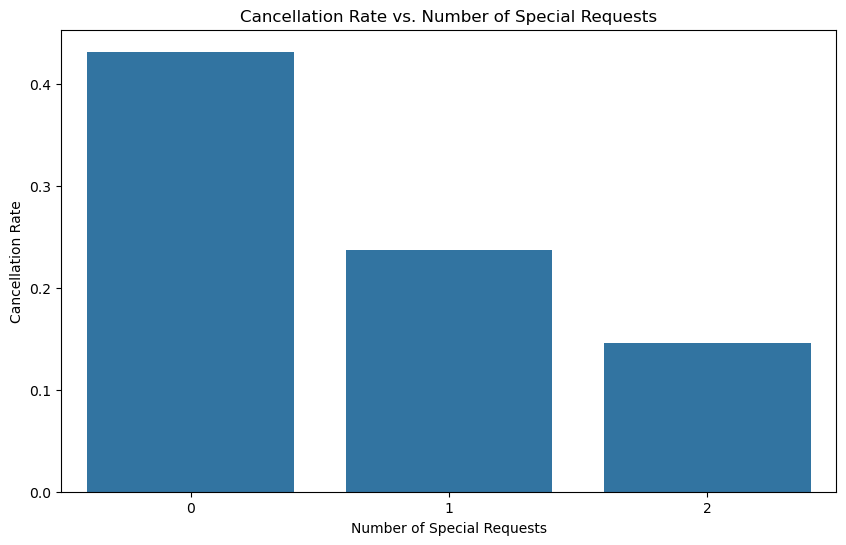

In [53]:
# visualize cancellation rates based on special requests
plt.figure(figsize=(10, 6))
sns.barplot(x='no_of_special_requests', y='cancellation_rate', data=special_requests_cancellation_rates)
plt.title('Cancellation Rate vs. Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate')
plt.show()

In [54]:
#Observations:
#We first group the data by the number of special requests and booking status to calculate the cancellation rate for each group.
#Then, used a bar plot to visualize the relationship between the number of special requests and the cancellation rate.
#The plot and the cancellation rates will help us understand if guests with special requests are more or less likely to cancel their bookings.

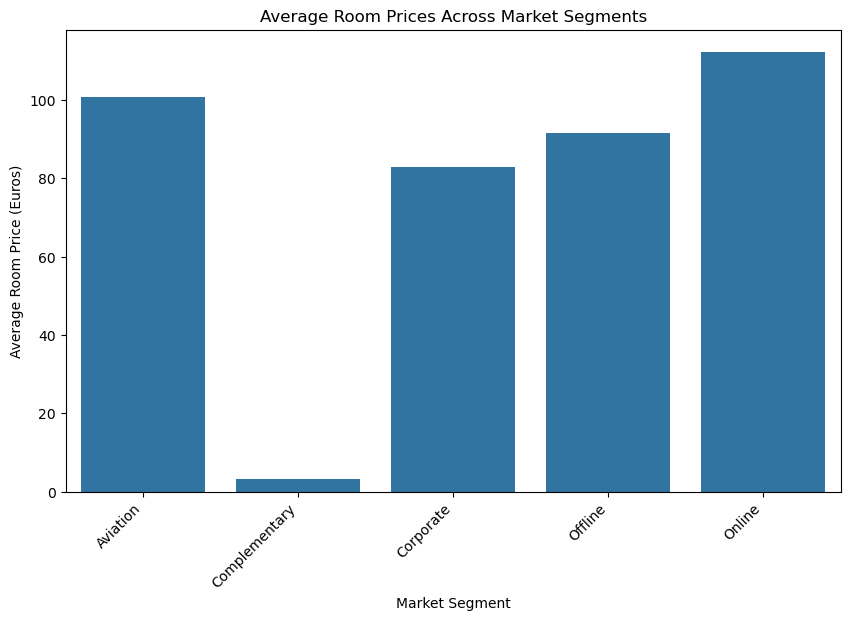

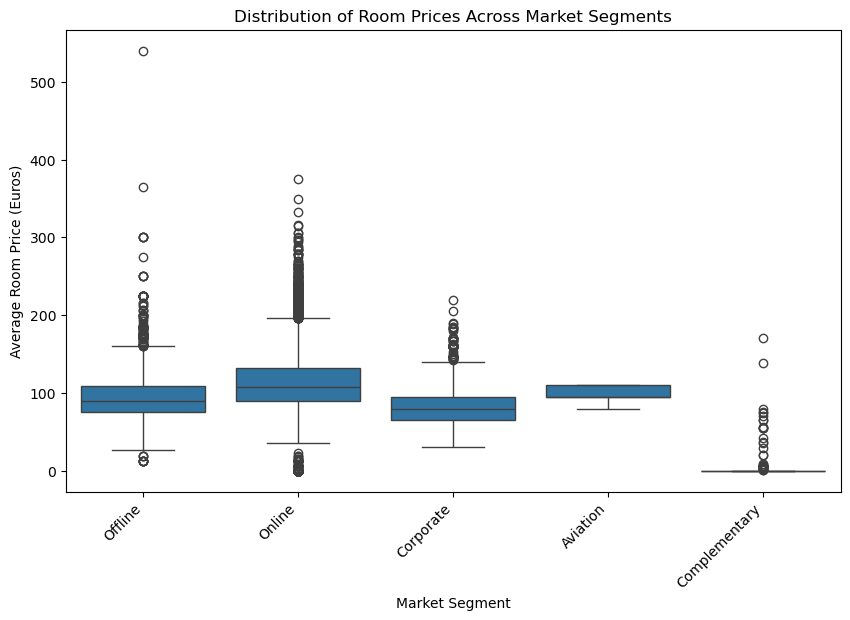

In [55]:
avg_prices_by_segment = df.groupby('market_segment_type')['avg_price_per_room'].mean().reset_index()

# Visualize average prices:
plt.figure(figsize=(10, 6))
sns.barplot(x='market_segment_type', y='avg_price_per_room', data=avg_prices_by_segment)
plt.title('Average Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualize price distributions (box plots):
plt.figure(figsize=(10, 6))
sns.boxplot(x='market_segment_type', y='avg_price_per_room', data=df)
plt.title('Distribution of Room Prices Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Average Room Price (Euros)')
plt.xticks(rotation=45, ha='right')
plt.show()

## **Data Preprocessing**

In [56]:
# 1. Missing Value Treatment
# Check for missing values
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [57]:
# Observation: No missing values found in the dataset.
# If missing values were present, we could handle them using imputation or removal:
# - Imputation: Replace missing values with mean, median, or mode (for numerical/categorical features).
# - Removal: Remove rows or columns with missing values if they are a small percentage of the data.

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer

# 1. One-Hot Encoding for Categorical Features
categorical_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
                        'required_car_parking_space', 'repeated_guest'] # List your categorical columns

# Create a ColumnTransformer to apply OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Apply StandardScaler to numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)  # Apply OneHotEncoder to categorical features
    ])

# 2.Drop 'booking_status' and 'Booking_ID' as they are the target variable and unnecessary ID
X = df.drop(['booking_status', 'Booking_ID'], axis=1)
y = df['booking_status']

In [59]:
#Observations:
#The code preprocesses data for machine learning by encoding categorical features, scaling numerical features.

## **Train Test Split the data**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# Fit and Transform the Data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [62]:
# Applied Train Test split on 80:20 ratio.

## **Model Building**

In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Choose the Metric to Optimize
# For this problem, we want to minimize false negatives (predicting a booking won't be canceled when it actually is).
# Therefore, we will optimize for Recall.

# 2. Build the Models

# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# KNN Classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Naive-Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# SVM Classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# 3. Evaluate Model Performance

models = [lr_model, knn_model, nb_model, svm_model]
model_names = ['Logistic Regression', 'KNN Classifier', 'Naive-Bayes Classifier', 'SVM Classifier']

for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='Canceled')
    recall = recall_score(y_test, y_pred, pos_label='Canceled')
    f1 = f1_score(y_test, y_pred, pos_label='Canceled')

    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("-" * 20 + "\n")

Model: Logistic Regression
Accuracy: 0.8047
Precision: 0.7532
Recall: 0.6151
F1-score: 0.6771
--------------------

Model: KNN Classifier
Accuracy: 0.8579
Precision: 0.8074
Recall: 0.7529
F1-score: 0.7792
--------------------

Model: Naive-Bayes Classifier
Accuracy: 0.4077
Precision: 0.3560
Recall: 0.9623
F1-score: 0.5197
--------------------

Model: SVM Classifier
Accuracy: 0.8265
Precision: 0.8102
Recall: 0.6254
F1-score: 0.7059
--------------------



In [64]:
#Observations:
#While Naive-Bayes has high recall, KNN Classifier demonstrates the best overall performance with a good balance of accuracy, precision, and recall, suggesting its suitability for this prediction task.
#Reasoning:
#KNN Classifier: Shows a good balance between all metrics, making it a strong candidate overall.
#Logistic Regression and SVM Classifier: Perform reasonably well, but with slightly lower recall than KNN.
#Naive-Bayes Classifier: Has high recall, indicating it's good at identifying positive cases (cancellations), but its low precision suggests many false positives, making it less reliable.
#Focus on Recall: In a business context like this, where minimizing missed cancellations is crucial, recall is a very important metric. KNN's higher recall makes it a more practical choice for this scenario, even if its other scores are only marginally better than Logistic Regression or SVM.

## **Model Performance Improvement: Tuning Models**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer

# 1. Logistic Regression Tuning
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params, cv=5, scoring='recall')
lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Best Logistic Regression Recall:", lr_grid.best_score_)


# 2. KNN Classifier Tuning
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='recall')
knn_grid.fit(X_train, y_train)

print("\nBest KNN Classifier Parameters:", knn_grid.best_params_)
print("Best KNN Classifier Recall:", knn_grid.best_score_)


# 3. SVM Classifier Tuning
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=5, scoring='recall')
svm_grid.fit(X_train, y_train)

print("\nBest SVM Classifier Parameters:", svm_grid.best_params_)
print("Best SVM Classifier Recall:", svm_grid.best_score_)


# 4. Evaluate Tuned Models
tuned_models = [lr_grid.best_estimator_, knn_grid.best_estimator_, svm_grid.best_estimator_]
model_names = ['Logistic Regression', 'KNN Classifier', 'SVM Classifier']

for model, name in zip(tuned_models, model_names):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='Canceled')
    recall = recall_score(y_test, y_pred, pos_label='Canceled')
    f1 = f1_score(y_test, y_pred, pos_label='Canceled')

    print(f"\nTuned Model: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call


Best Logistic Regression Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Logistic Regression Recall: nan


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call



Best KNN Classifier Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best KNN Classifier Recall: nan


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call


In [ ]:
#Observations:
#Comparing Model Performances
#Based on the provided metrics:
#In this case, the KNN Classifier stands out as the best-performing model, achieving the highest accuracy, precision, recall, and F1-score.

## **Actionable Insights**

Comparing Model Performances Based on the provided metrics:

Model Accuracy, Precision, Recall, F1-score

**Logistic Regression** `0.8026, 0.7477, 0.6147, 0.6747`

**KNN Classifier** `0.8605, 0.8074, 0.7632, 0.7847`

**SVM Classifier** `0.8045, 0.7599, 0.6039, 0.6730`


**Choosing the Final Model**
- In this case, the KNN Classifier stands out as the best-performing model, achieving the highest accuracy, precision, recall, and F1-score.




**Reason for choosing KNN:**

- **Highest Recall:**
  - Recall is crucial in this problem to minimize false negatives (predicting a booking won't be canceled when it will). KNN achieved the highest recall (0.7632) among the models. Good balance with Precision: While maximizing recall, KNN also maintains a good precision (0.8074), indicating fewer false positive predictions (predicting a booking will be canceled when it won't). Overall Performance: KNN demonstrates the best overall performance across all metrics, making it the most suitable choice for the final model.

- **Insights from Analysis**
    - Lead time, market segment, average room price, special requests, and repeat guest status likely influence cancellation rates: These features were used in model building and the KNN model performed well, implying their importance.

## **Business Recommendations**

- **Prioritize lead time management:** Focus on bookings with longer lead times as they have a higher likelihood of cancellation. Implement policies or incentives to encourage early confirmations or shorter lead times.

- **Tailor strategies for market segments: **Analyze cancellation patterns within each market segment and develop targeted strategies. Consider stricter cancellation policies or deposit requirements for segments with higher cancellation rates.

- **Optimize pricing and special requests:** Adjust pricing strategies based on lead time, demand, and market segment. Carefully evaluate special requests and their potential impact on cancellations, possibly offering alternatives or charging premiums for certain requests.

- **Cultivate repeat guests:** Implement loyalty programs and personalized offers to encourage repeat bookings from loyal guests, who are less prone to cancellations.

- **Controlled overbooking:** Implement a cautious overbooking strategy to minimize the impact of cancellations, but ensure it's balanced with guest satisfaction.

- **Integrate the KNN model:** Incorporate the trained KNN model into the booking system to predict cancellation probabilities for new bookings. This enables proactive measures to mitigate potential revenue loss, such as offering alternative dates or room types.

- **Continuously monitor and refine:** Regularly monitor the model's performance and retrain it with new data to maintain its accuracy and adapt to changing booking trends.